<h1 align="center">Analise</h1>

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

In [2]:
def resolve_support_images() -> Path:
    """Find support_images next to cwd or one level up (e.g. running from notebook/)."""
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent):
        candidate = base / "support_images"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find support_images/. Run the notebook from the project root or from notebook/."
    )

In [3]:
SUPPORT_IMAGES = resolve_support_images()
print(SUPPORT_IMAGES)

/home/jpolonip/Documents/Personal/pytorch-unet/support_images


In [4]:
def find_csv_files(root: Path) -> list[Path]:
    return sorted(root.rglob("*.csv"))

In [19]:
raw = find_csv_files(SUPPORT_IMAGES)
# print(list(raw))

valid_data = [
    "20260504_005306_preds_imagem_regular_200_epocas_10_folds_dice",
    "20260510_191013_preds_vessel_regular_200_epocas_10_folds_dice",
    "20260504_081718_preds_imagem_regular_200_epocas_10_folds_bce",
    "20260511_165927_preds_vessel_regular_200_epocas_10_folds_bce",
    "20260510_024020_preds_imagem_regular_200_epocas_10_folds_dice_bce_swap_0",
    "20260515_001931_preds_vessel_regular_200_epocas_10_folds_dice_bce_swap_0",
    "20260504_231233_preds_imagem_edge_200_epocas_10_folds_dice",
    "20260513_035403_preds_vessel_edge_200_epocas_10_folds_dice",
    "20260517_045850_preds_imagem_edge_200_epocas_10_folds_dice_unet_simples",
    "20260515_205409_preds_vessel_regular_200_epocas_10_folds_dice_unet_simples",
    "20260505_081932_preds_imagem_edge_200_epocas_10_folds_dice_unet_simples_informacao_de_borda",
    "20260515_103607_preds_vessel_edge_200_epocas_10_folds_dice_unet_simples_informacao_de_borda",
    "20260505_123138_preds_imagem_regular_200_epocas_10_folds_dice_unet_simples_menos_camadas",
    "20260513_190824_preds_vessel_regular_200_epocas_10_folds_dice_unet_simples_menos_camadas",
    "20260516_141125_preds_imagem_edge_200_epocas_10_folds_dice_unet_simples_menos_camadas",
    "20260516_192822_preds_vessel_edge_200_epocas_10_folds_dice_unet_simples_menos_camadas"
]

csv_paths = list(filter(lambda x: x.parents[0].stem in valid_data, raw))
print(f"Found {len(csv_paths)} CSV file(s)")
for p in csv_paths:
    print(" ", p.relative_to(SUPPORT_IMAGES))

Found 16 CSV file(s)
  20260504_005306_preds_imagem_regular_200_epocas_10_folds_dice/logs.csv
  20260504_081718_preds_imagem_regular_200_epocas_10_folds_bce/logs.csv
  20260504_231233_preds_imagem_edge_200_epocas_10_folds_dice/logs.csv
  20260505_081932_preds_imagem_edge_200_epocas_10_folds_dice_unet_simples_informacao_de_borda/logs.csv
  20260505_123138_preds_imagem_regular_200_epocas_10_folds_dice_unet_simples_menos_camadas/logs.csv
  20260510_024020_preds_imagem_regular_200_epocas_10_folds_dice_bce_swap_0.5/logs.csv
  20260510_191013_preds_vessel_regular_200_epocas_10_folds_dice/logs.csv
  20260511_165927_preds_vessel_regular_200_epocas_10_folds_bce/logs.csv
  20260513_035403_preds_vessel_edge_200_epocas_10_folds_dice/logs.csv
  20260513_190824_preds_vessel_regular_200_epocas_10_folds_dice_unet_simples_menos_camadas/logs.csv
  20260515_001931_preds_vessel_regular_200_epocas_10_folds_dice_bce_swap_0.5/logs.csv
  20260515_103607_preds_vessel_edge_200_epocas_10_folds_dice_unet_simples_

In [20]:
def load_csv(path: Path, **read_csv_kwargs) -> pd.DataFrame:
    return pd.read_csv(path, **read_csv_kwargs)

In [21]:
def load_all_csv(root: Path, **read_csv_kwargs) -> dict[str, pd.DataFrame]:
    out: dict[str, pd.DataFrame] = {}
    for path in find_csv_files(root):
        if path.parents[0].stem in valid_data:
            key = str(path.relative_to(root))
            out[key] = load_csv(path, **read_csv_kwargs)
    return out

In [22]:
tables = load_all_csv(SUPPORT_IMAGES)
list(tables.keys())

['20260504_005306_preds_imagem_regular_200_epocas_10_folds_dice/logs.csv',
 '20260504_081718_preds_imagem_regular_200_epocas_10_folds_bce/logs.csv',
 '20260504_231233_preds_imagem_edge_200_epocas_10_folds_dice/logs.csv',
 '20260505_081932_preds_imagem_edge_200_epocas_10_folds_dice_unet_simples_informacao_de_borda/logs.csv',
 '20260505_123138_preds_imagem_regular_200_epocas_10_folds_dice_unet_simples_menos_camadas/logs.csv',
 '20260510_024020_preds_imagem_regular_200_epocas_10_folds_dice_bce_swap_0.5/logs.csv',
 '20260510_191013_preds_vessel_regular_200_epocas_10_folds_dice/logs.csv',
 '20260511_165927_preds_vessel_regular_200_epocas_10_folds_bce/logs.csv',
 '20260513_035403_preds_vessel_edge_200_epocas_10_folds_dice/logs.csv',
 '20260513_190824_preds_vessel_regular_200_epocas_10_folds_dice_unet_simples_menos_camadas/logs.csv',
 '20260515_001931_preds_vessel_regular_200_epocas_10_folds_dice_bce_swap_0.5/logs.csv',
 '20260515_103607_preds_vessel_edge_200_epocas_10_folds_dice_unet_simples


--- 20260504_005306_preds_imagem_regular_200_epocas_10_folds_dice/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.378680,0.621320,3.084394,0.707576,0.297781,0.378323,0.424100,0.575900,4.875422,0.835973,0.389590,0.424096
1,0.0,1.0,0.504362,0.495638,1.832972,0.845309,0.468325,0.516377,0.613006,0.386994,0.225362,0.899172,0.684103,0.620097
2,0.0,2.0,0.657423,0.342577,0.346729,0.900985,0.635467,0.670193,0.634207,0.365793,0.309287,0.906535,0.695132,0.638613
3,0.0,3.0,0.695368,0.304631,0.375603,0.910465,0.675278,0.700936,0.700028,0.299972,0.412014,0.910485,0.622710,0.709742
4,0.0,4.0,0.719413,0.280587,0.417101,0.914409,0.692332,0.722159,0.662608,0.337392,0.541014,0.907534,0.756486,0.660188


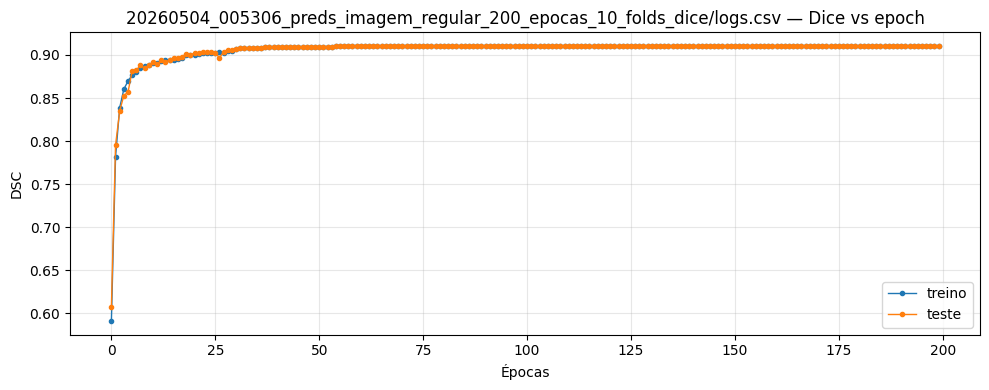

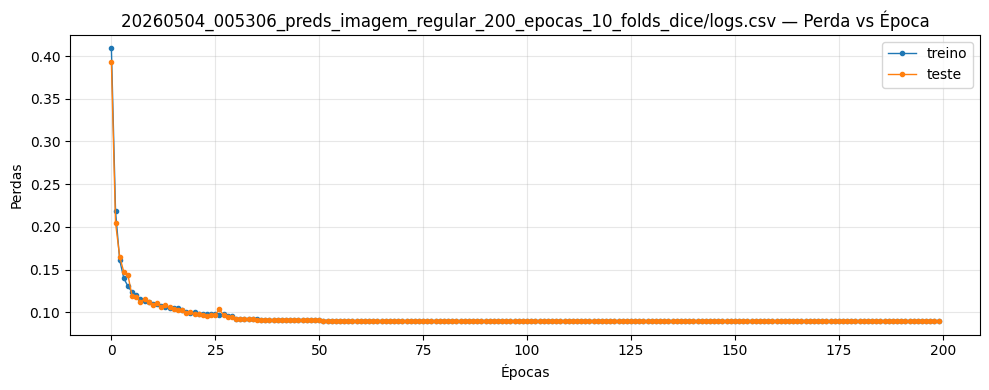


--- 20260504_081718_preds_imagem_regular_200_epocas_10_folds_bce/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.252379,0.243144,0.243144,0.865179,0.368426,0.129672,0.315275,0.188584,0.188584,0.867677,0.657443,0.226717
1,0.0,1.0,0.466944,0.138696,0.138696,0.899139,0.624741,0.555219,0.581680,0.112353,0.112353,0.911527,0.596236,0.668015
2,0.0,2.0,0.603228,0.088482,0.088482,0.921058,0.711992,0.679744,0.631751,0.067501,0.067501,0.933161,0.756133,0.695662
3,0.0,3.0,0.673874,0.065153,0.065153,0.930045,0.782413,0.739231,0.677138,0.061965,0.061965,0.928834,0.768661,0.750744
4,0.0,4.0,0.701796,0.057742,0.057742,0.932307,0.813808,0.766542,0.741327,0.056210,0.056210,0.928769,0.823740,0.809206


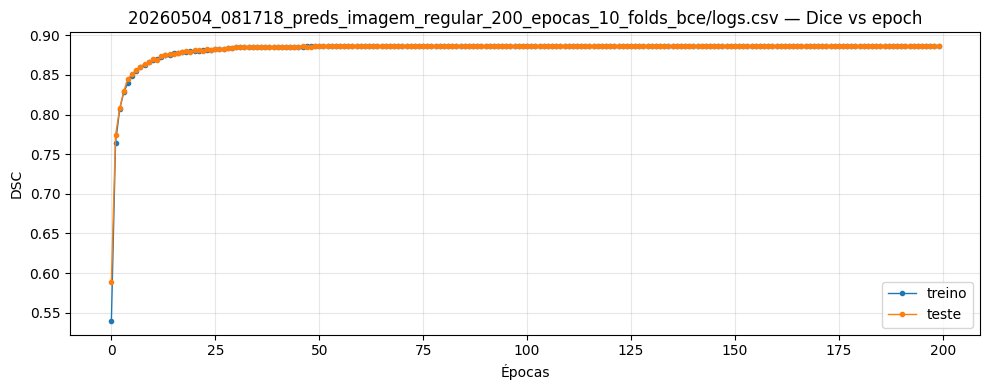

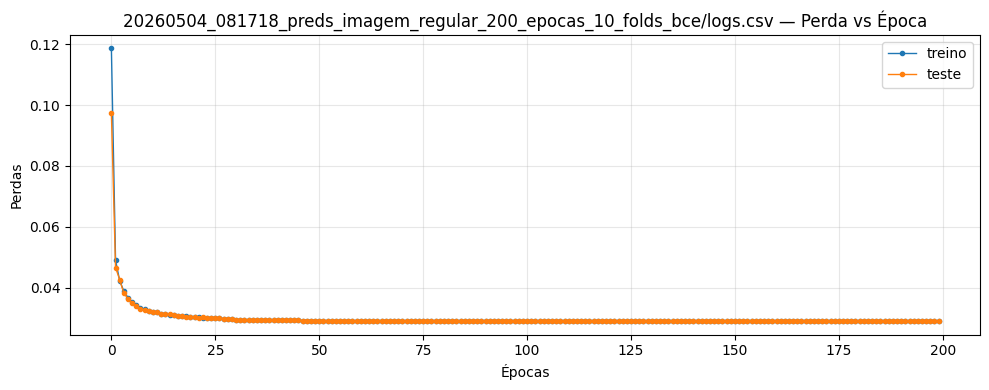


--- 20260504_231233_preds_imagem_edge_200_epocas_10_folds_dice/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.620195,0.379804,4.016149,0.818426,0.525436,0.630033,0.730759,0.269241,3.550225,0.893250,0.667043,0.725563
1,0.0,1.0,0.774112,0.225887,3.513576,0.902836,0.664642,0.767663,0.790816,0.209185,2.780022,0.906051,0.678290,0.778631
2,0.0,2.0,0.801731,0.198269,1.231322,0.910895,0.704962,0.794281,0.785011,0.214989,1.147776,0.910232,0.695582,0.777506
3,0.0,3.0,0.818077,0.181924,0.508141,0.917303,0.730642,0.810167,0.816894,0.183106,0.492128,0.917500,0.720608,0.809408
4,0.0,4.0,0.827522,0.172478,0.372829,0.922711,0.745092,0.818851,0.825790,0.174210,0.340538,0.916474,0.755828,0.821862


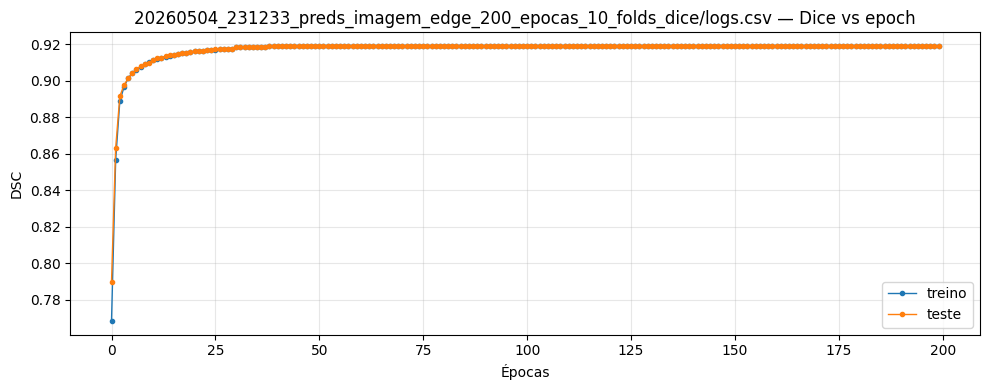

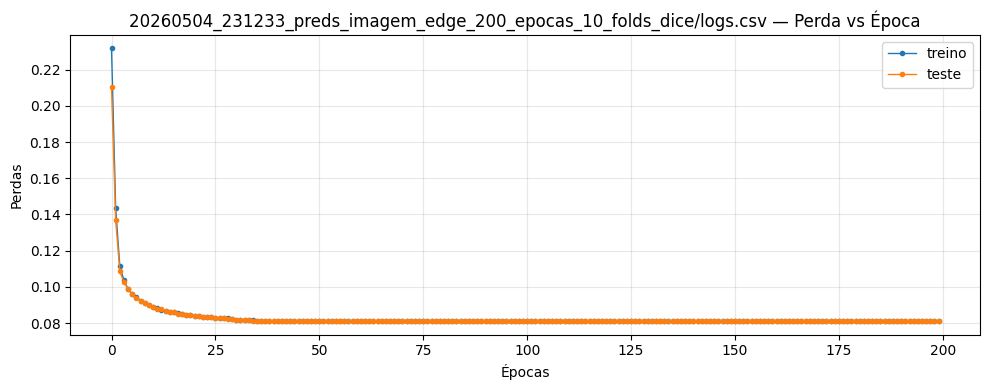


--- 20260505_081932_preds_imagem_edge_200_epocas_10_folds_dice_unet_simples_informacao_de_borda/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.634359,0.365641,4.334785,0.841756,0.539567,0.647179,0.743301,0.256699,4.081248,0.896755,0.633062,0.735455
1,0.0,1.0,0.757127,0.242872,1.528245,0.898413,0.643625,0.751597,0.783966,0.216035,0.479441,0.904091,0.675201,0.772632
2,0.0,2.0,0.791041,0.208958,0.375998,0.908223,0.693757,0.784466,0.818496,0.181504,0.250191,0.921605,0.736706,0.813762
3,0.0,3.0,0.819582,0.180418,0.301365,0.918099,0.733954,0.812596,0.817300,0.182700,0.265075,0.919837,0.743038,0.813094
4,0.0,4.0,0.826470,0.173530,0.284571,0.921893,0.742226,0.818178,0.829073,0.170927,0.254446,0.916939,0.749884,0.825169


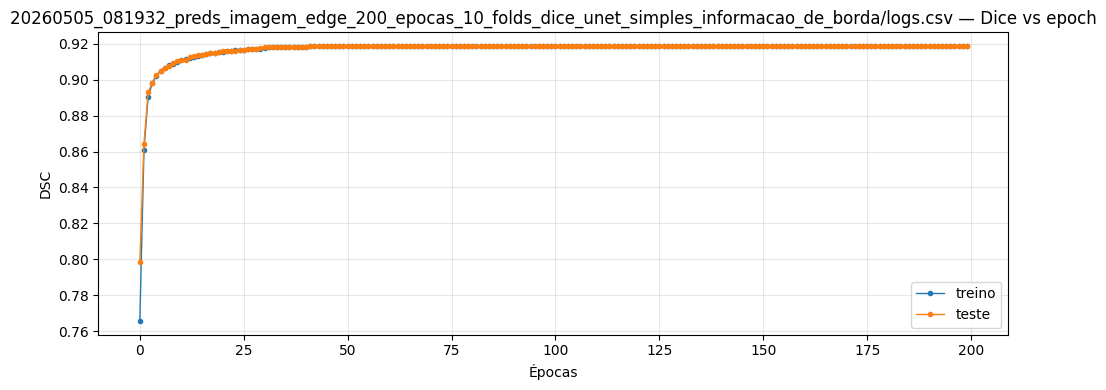

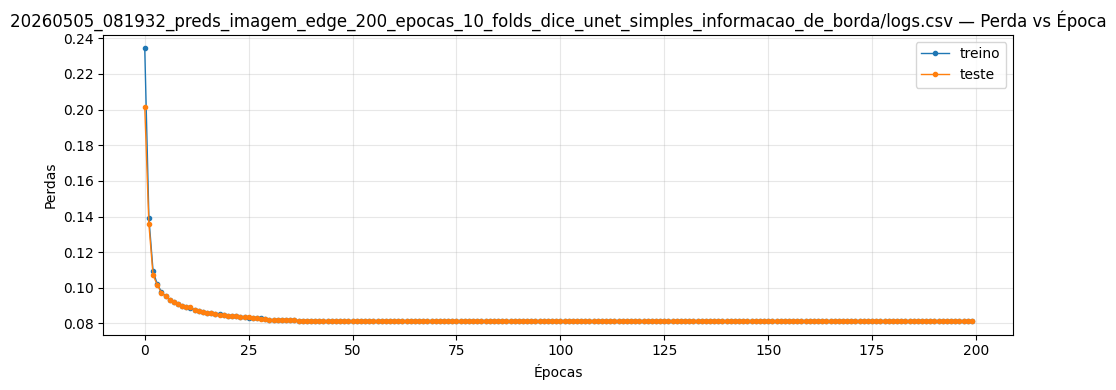


--- 20260505_123138_preds_imagem_regular_200_epocas_10_folds_dice_unet_simples_menos_camadas/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.391364,0.608636,1.532748,0.689475,0.313946,0.394371,0.469690,0.530310,0.643861,0.834693,0.405936,0.472029
1,0.0,1.0,0.533500,0.466500,0.481323,0.870432,0.543121,0.558196,0.633722,0.366277,0.332733,0.908782,0.693950,0.652147
2,0.0,2.0,0.652756,0.347244,0.455717,0.905059,0.650626,0.668309,0.685964,0.314036,0.477424,0.917689,0.690857,0.695976
3,0.0,3.0,0.684211,0.315789,0.654773,0.910526,0.670824,0.692961,0.704781,0.295219,0.731521,0.913848,0.658458,0.712734
4,0.0,4.0,0.687622,0.312377,0.892775,0.909153,0.670978,0.691548,0.694794,0.305206,0.798004,0.906124,0.735968,0.692164


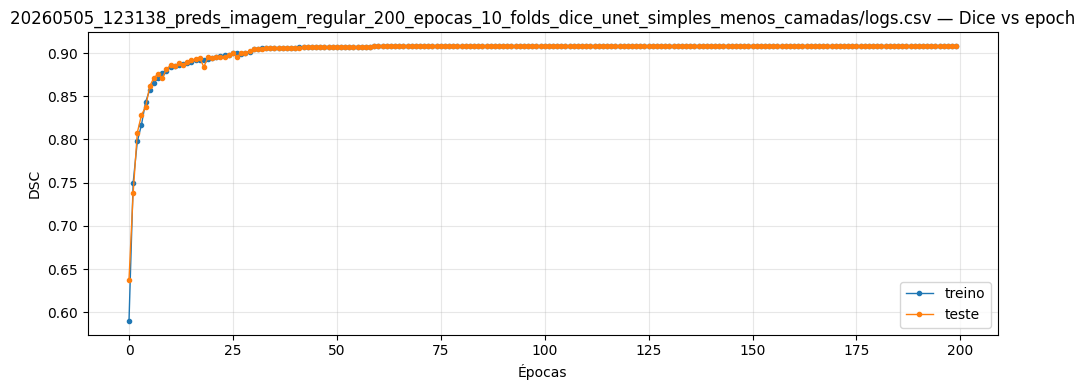

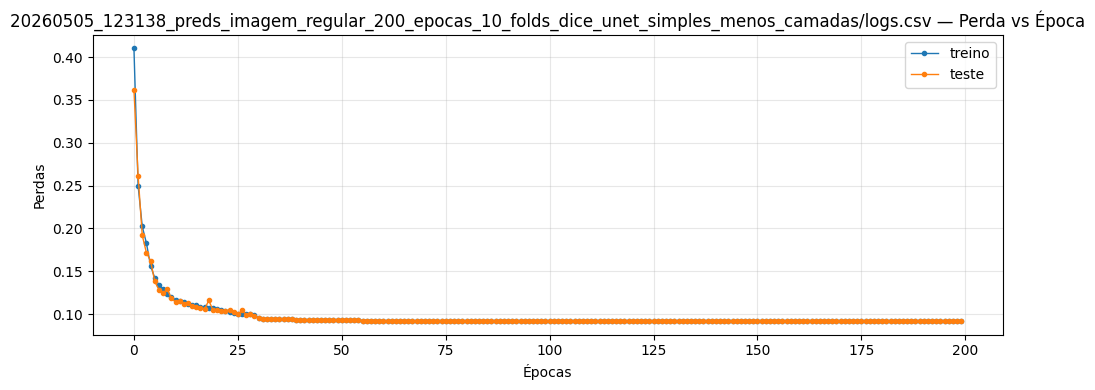


--- 20260510_024020_preds_imagem_regular_200_epocas_10_folds_dice_bce_swap_0.5/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.365223,0.634776,2.358632,0.666725,0.286506,0.366841,0.431247,0.568753,2.052422,0.797075,0.361999,0.431622
1,0.0,1.0,0.450343,0.549657,1.873486,0.811249,0.389570,0.453254,0.621130,0.378870,0.553123,0.903511,0.619841,0.639970
2,0.0,2.0,0.642123,0.357877,0.661115,0.900599,0.629214,0.650986,0.672908,0.327092,0.709026,0.913625,0.654987,0.675235
3,0.0,3.0,0.709801,0.290199,0.704498,0.911669,0.683584,0.712748,0.714832,0.285168,0.704131,0.914777,0.650123,0.720004
4,0.0,4.0,0.745835,0.254165,0.799687,0.918589,0.712986,0.745180,0.758510,0.241490,1.024439,0.912178,0.686031,0.762181


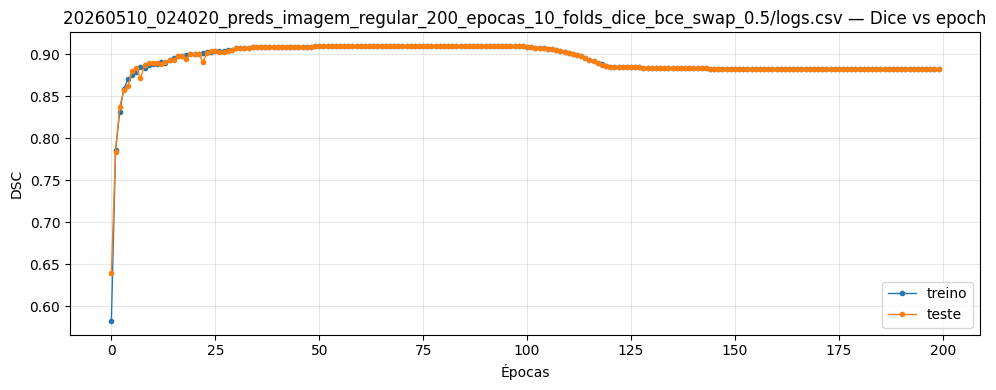

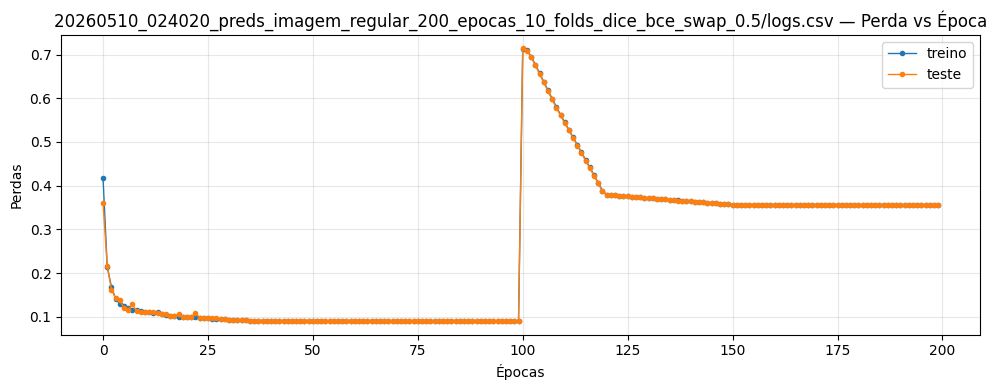


--- 20260510_191013_preds_vessel_regular_200_epocas_10_folds_dice/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.583012,0.416988,1.007024,0.912434,0.575533,0.543779,0.726989,0.273011,0.235411,0.965967,0.762888,0.637172
1,0.0,1.0,0.683306,0.316693,0.777574,0.961107,0.641618,0.585729,0.699496,0.300504,0.606526,0.957184,0.727888,0.565186
2,0.0,2.0,0.722181,0.277819,0.796981,0.965502,0.667981,0.615166,0.653829,0.346171,1.862870,0.965148,0.629409,0.614474
3,0.0,3.0,0.694808,0.305193,1.600774,0.954787,0.617448,0.560041,0.776643,0.223357,0.787595,0.979295,0.649466,0.685313
4,0.0,4.0,0.758573,0.241427,0.749714,0.969508,0.647039,0.613233,0.820280,0.179720,0.899431,0.975018,0.703357,0.705828


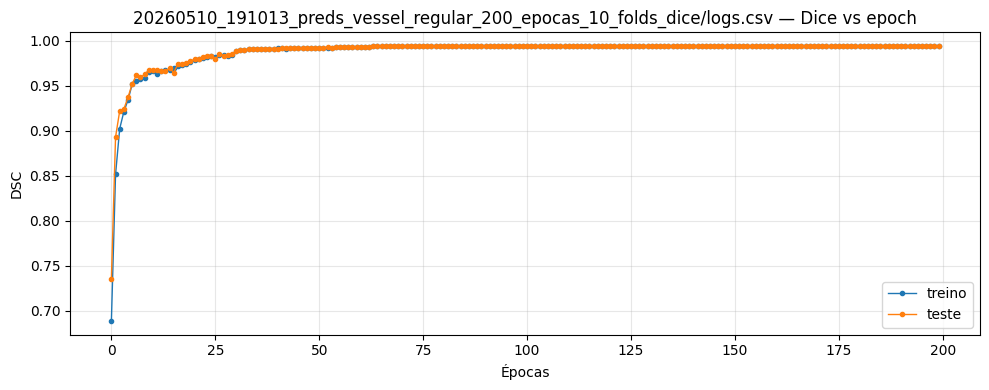

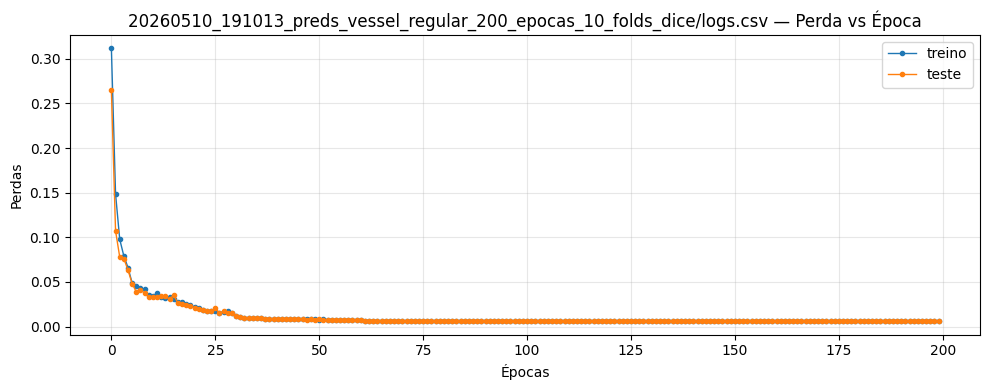


--- 20260511_165927_preds_vessel_regular_200_epocas_10_folds_bce/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.556126,0.111464,0.111464,0.958934,0.603356,0.557094,0.719886,0.035542,0.035542,0.989414,0.756460,0.755759
1,0.0,1.0,0.718080,0.034136,0.034136,0.989144,0.756678,0.745667,0.736109,0.026134,0.026134,0.991356,0.744255,0.751603
2,0.0,2.0,0.737317,0.030868,0.030868,0.989985,0.766594,0.755391,0.742312,0.021591,0.021591,0.993084,0.752218,0.754773
3,0.0,3.0,0.775687,0.021313,0.021313,0.992888,0.779127,0.770724,0.788971,0.020411,0.020411,0.993171,0.774021,0.746272
4,0.0,4.0,0.768305,0.022952,0.022952,0.992450,0.770593,0.762889,0.785574,0.017042,0.017042,0.994314,0.796619,0.794096


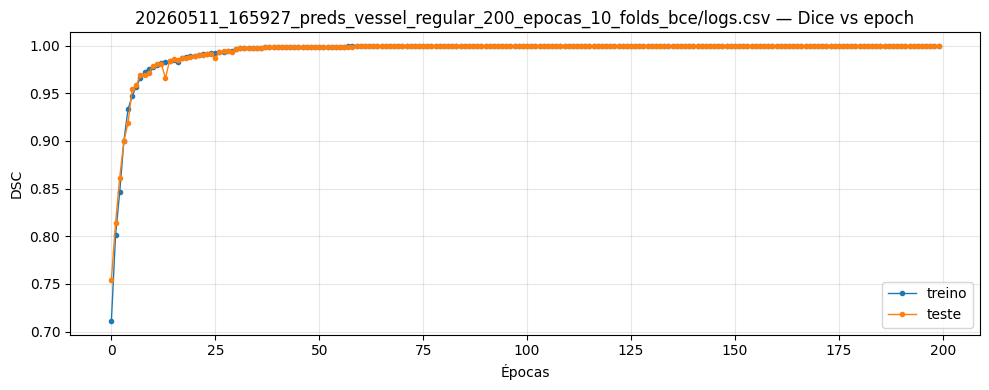

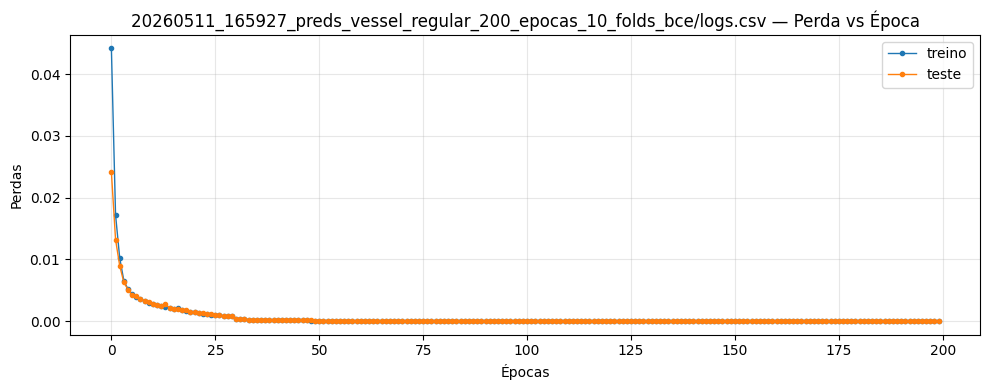


--- 20260513_035403_preds_vessel_edge_200_epocas_10_folds_dice/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.737109,0.262890,0.349569,0.926308,0.615285,0.637597,0.910705,0.089295,0.060044,0.986523,0.766443,0.767930
1,0.0,1.0,0.935484,0.064516,0.059941,0.989903,0.774702,0.772130,0.958045,0.041955,0.025249,0.993693,0.797022,0.780729
2,0.0,2.0,0.961765,0.038235,0.022054,0.994503,0.801033,0.799716,0.967448,0.032552,0.016802,0.995777,0.777021,0.783382
3,0.0,3.0,0.967785,0.032215,0.021252,0.995680,0.803960,0.802681,0.955992,0.044007,0.038520,0.994960,0.804746,0.781957
4,0.0,4.0,0.972560,0.027440,0.018862,0.996510,0.803130,0.800879,0.979731,0.020269,0.009059,0.997782,0.834438,0.829557


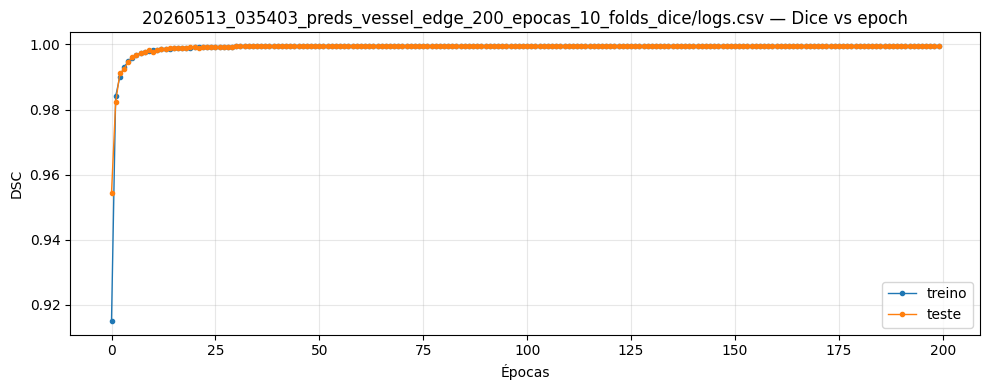

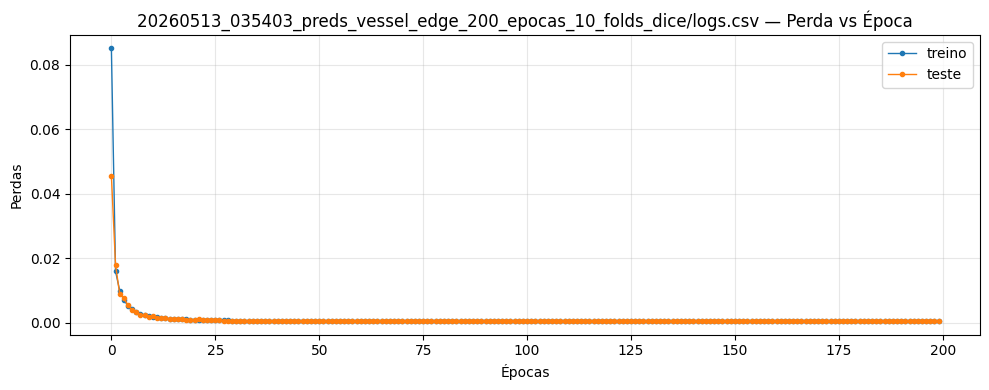


--- 20260513_190824_preds_vessel_regular_200_epocas_10_folds_dice_unet_simples_menos_camadas/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.572482,0.427518,0.477055,0.886941,0.569483,0.548754,0.777600,0.222400,0.571959,0.971986,0.756138,0.693265
1,0.0,1.0,0.732655,0.267345,0.448316,0.969378,0.684239,0.631218,0.670856,0.329144,0.678731,0.951536,0.557398,0.505937
2,0.0,2.0,0.756322,0.243678,0.531566,0.970262,0.689646,0.645600,0.667395,0.332605,0.703509,0.957398,0.556315,0.502350
3,0.0,3.0,0.745559,0.254442,0.634040,0.967562,0.682598,0.621596,0.769045,0.230955,0.350946,0.976277,0.736068,0.659184
4,0.0,4.0,0.783142,0.216858,0.554899,0.973577,0.694981,0.653554,0.629075,0.370924,1.076635,0.948382,0.557793,0.492332


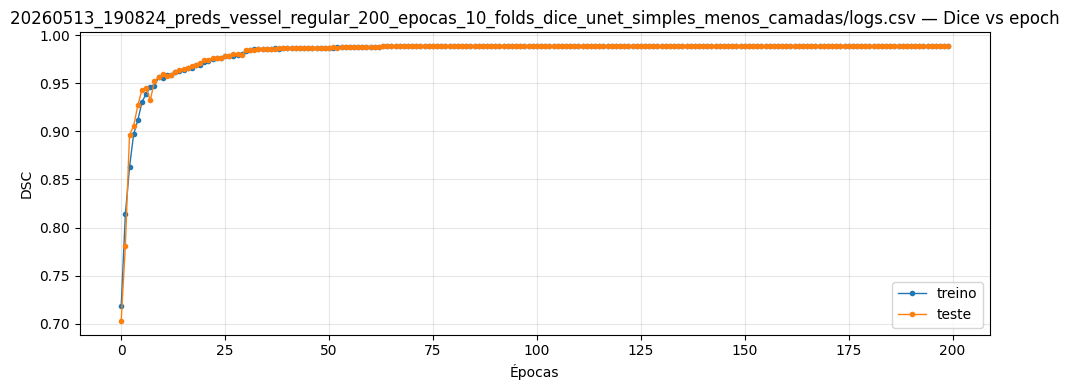

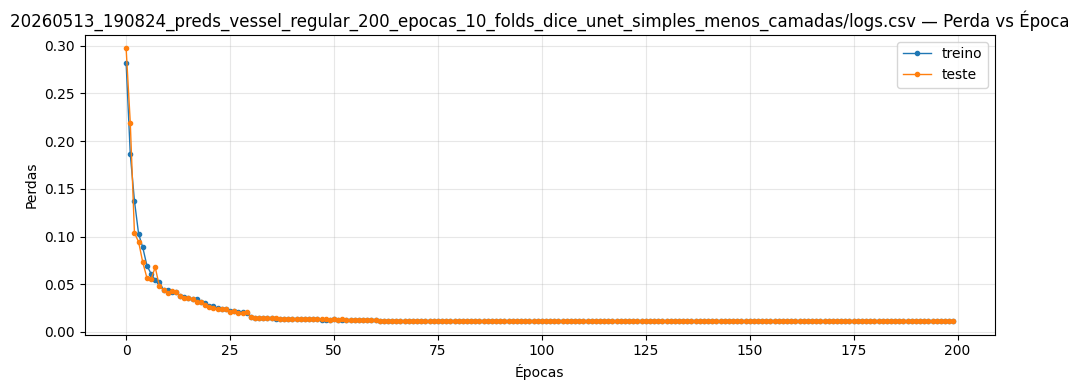


--- 20260515_001931_preds_vessel_regular_200_epocas_10_folds_dice_bce_swap_0.5/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.590201,0.409799,0.577272,0.911162,0.561319,0.536797,0.798871,0.201129,0.223941,0.981838,0.730742,0.727467
1,0.0,1.0,0.673255,0.326746,0.988435,0.956298,0.629426,0.574402,0.792128,0.207873,0.324695,0.979730,0.705951,0.702563
2,0.0,2.0,0.707627,0.292372,0.860150,0.961241,0.634319,0.594879,0.688086,0.311914,0.655095,0.961510,0.560399,0.527319
3,0.0,3.0,0.709486,0.290514,0.832351,0.962324,0.627939,0.579848,0.697144,0.302856,0.768321,0.963499,0.582870,0.539266
4,0.0,4.0,0.711061,0.288939,1.129284,0.961628,0.593600,0.555162,0.808373,0.191627,1.610086,0.966064,0.744394,0.656075


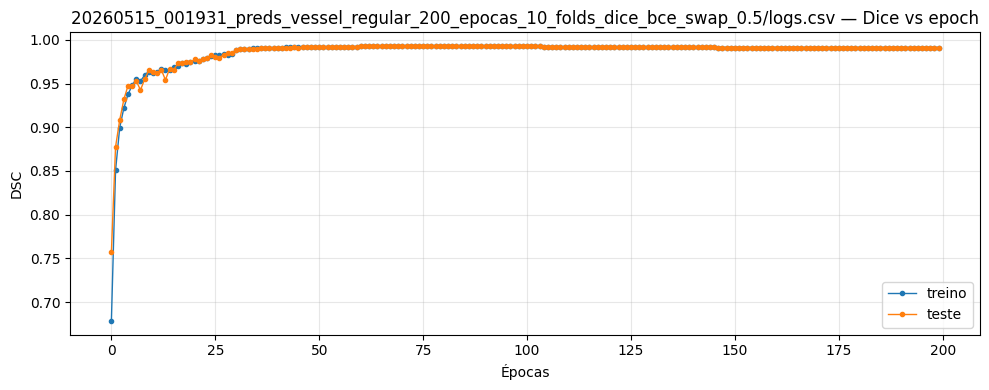

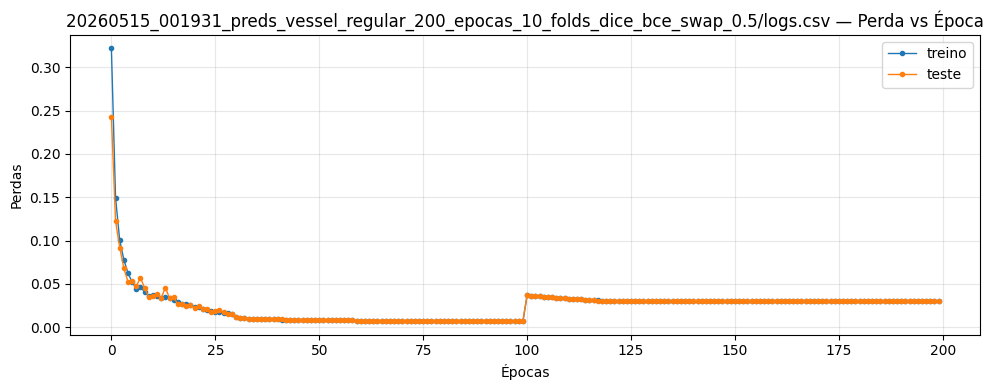


--- 20260515_103607_preds_vessel_edge_200_epocas_10_folds_dice_unet_simples_informacao_de_borda/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.737345,0.262655,0.242828,0.927226,0.625682,0.646790,0.926991,0.073009,0.045196,0.987624,0.737589,0.773316
1,0.0,1.0,0.935540,0.064460,0.113916,0.989872,0.776272,0.773006,0.957956,0.042044,0.024523,0.993923,0.797020,0.781141
2,0.0,2.0,0.957563,0.042436,0.055588,0.993888,0.797658,0.796275,0.970982,0.029018,0.014965,0.996254,0.787861,0.786226
3,0.0,3.0,0.971244,0.028757,0.015555,0.996113,0.804981,0.804622,0.976231,0.023769,0.011620,0.997031,0.801638,0.804219
4,0.0,4.0,0.975990,0.024011,0.014436,0.996949,0.803916,0.803411,0.981013,0.018987,0.008724,0.997834,0.833739,0.830372


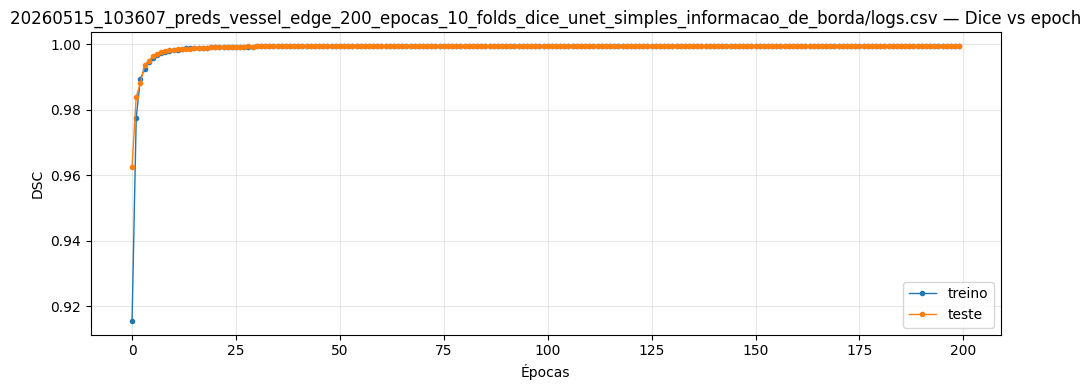

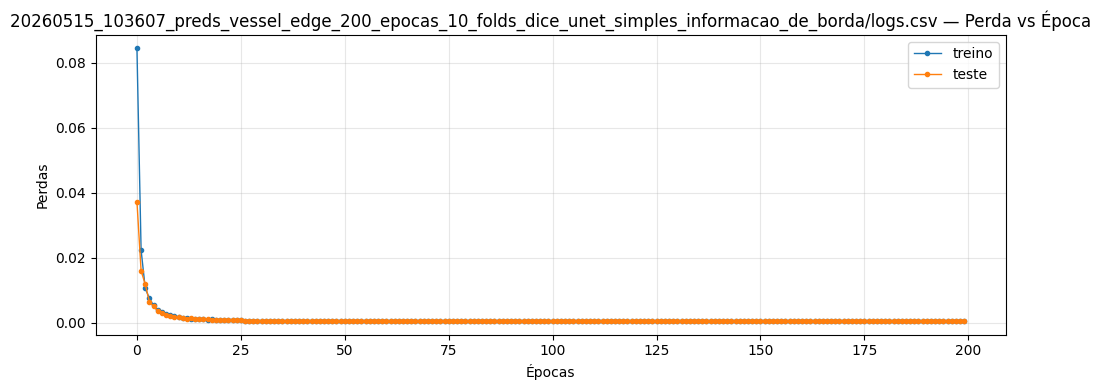


--- 20260515_205409_preds_vessel_regular_200_epocas_10_folds_dice_unet_simples/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.546869,0.453131,6.411916,0.825967,0.533245,0.504675,0.500583,0.499417,2.698945,0.922641,0.566165,0.366215
1,0.0,1.0,0.665509,0.334492,1.268870,0.958337,0.634743,0.570250,0.684714,0.315286,1.006057,0.975142,0.641456,0.679094
2,0.0,2.0,0.666461,0.333539,1.662086,0.956496,0.624079,0.545783,0.671627,0.328373,1.444653,0.957317,0.554164,0.502751
3,0.0,3.0,0.709776,0.290224,1.391243,0.964112,0.643558,0.597262,0.749058,0.250942,1.040440,0.980480,0.657222,0.685161
4,0.0,4.0,0.689386,0.310613,1.940454,0.958214,0.626958,0.563112,0.542244,0.457756,3.108589,0.934218,0.530972,0.406984


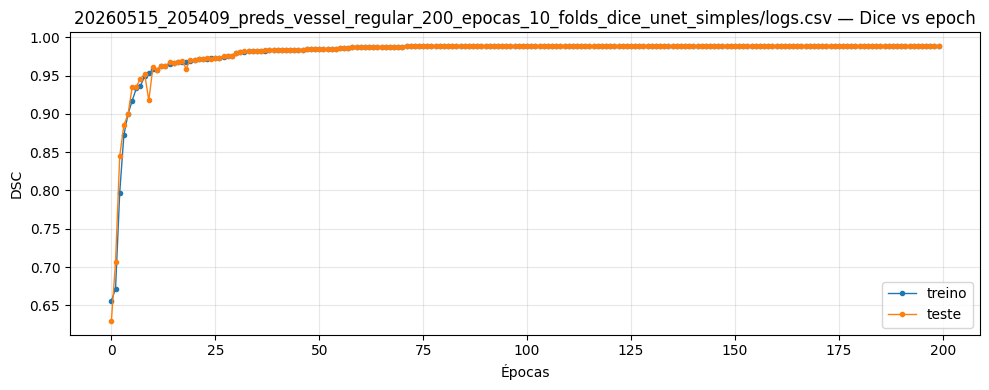

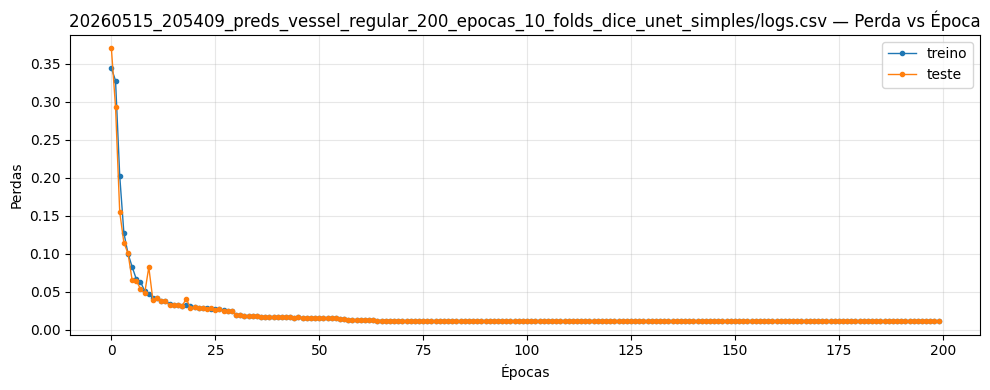


--- 20260516_141125_preds_imagem_edge_200_epocas_10_folds_dice_unet_simples_menos_camadas/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.568251,0.431749,3.012001,0.785353,0.471334,0.582657,0.712890,0.287110,2.636777,0.891492,0.626621,0.717745
1,0.0,1.0,0.744970,0.255029,1.845162,0.898040,0.629763,0.742252,0.775523,0.224477,0.608867,0.906764,0.662319,0.768516
2,0.0,2.0,0.779963,0.220037,0.504268,0.908110,0.671767,0.775227,0.795138,0.204862,0.420170,0.916121,0.687255,0.788999
3,0.0,3.0,0.798209,0.201791,0.386595,0.914478,0.699775,0.792160,0.775449,0.224551,0.609161,0.908344,0.650284,0.769288
4,0.0,4.0,0.807578,0.192421,0.358341,0.918468,0.713167,0.800352,0.810896,0.189104,0.338362,0.913298,0.725755,0.808224


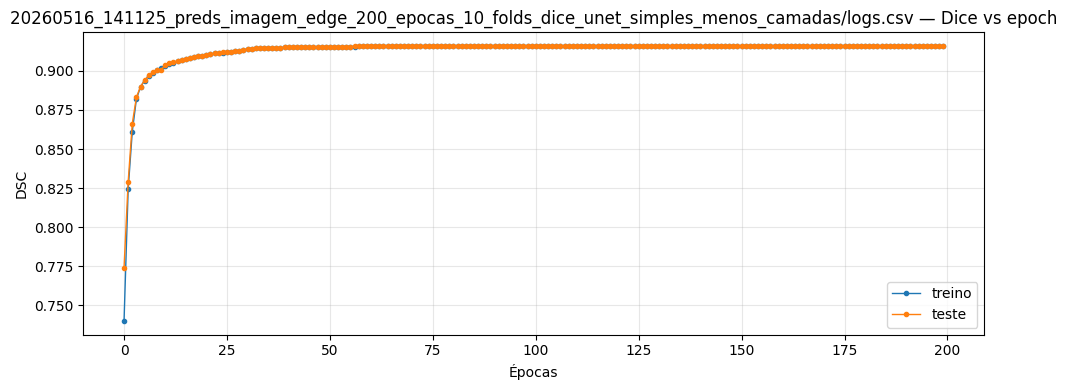

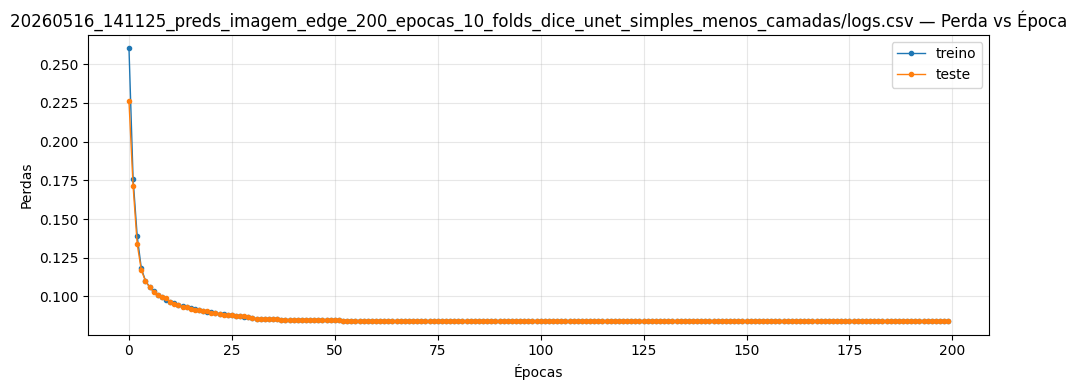


--- 20260516_192822_preds_vessel_edge_200_epocas_10_folds_dice_unet_simples_menos_camadas/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.670242,0.329758,0.289473,0.945478,0.607527,0.595944,0.827086,0.172914,0.150248,0.970583,0.746485,0.698952
1,0.0,1.0,0.872861,0.127138,0.170960,0.980127,0.721734,0.730794,0.866335,0.133665,0.083105,0.976370,0.771779,0.702059
2,0.0,2.0,0.933081,0.066920,0.050298,0.988734,0.765880,0.773429,0.894753,0.105246,0.366412,0.983044,0.740037,0.709699
3,0.0,3.0,0.946095,0.053905,0.053240,0.991342,0.780373,0.780747,0.955703,0.044297,0.031033,0.993173,0.777885,0.784737
4,0.0,4.0,0.955672,0.044328,0.032506,0.993063,0.784568,0.785223,0.962269,0.037731,0.025379,0.994336,0.818760,0.812086


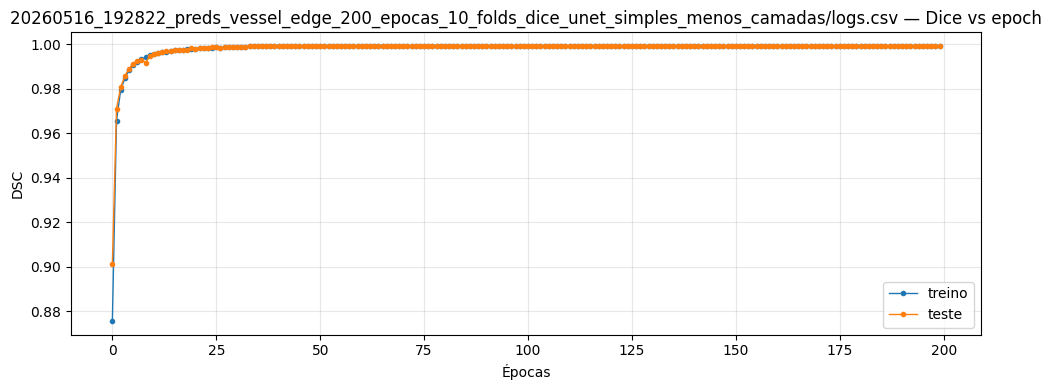

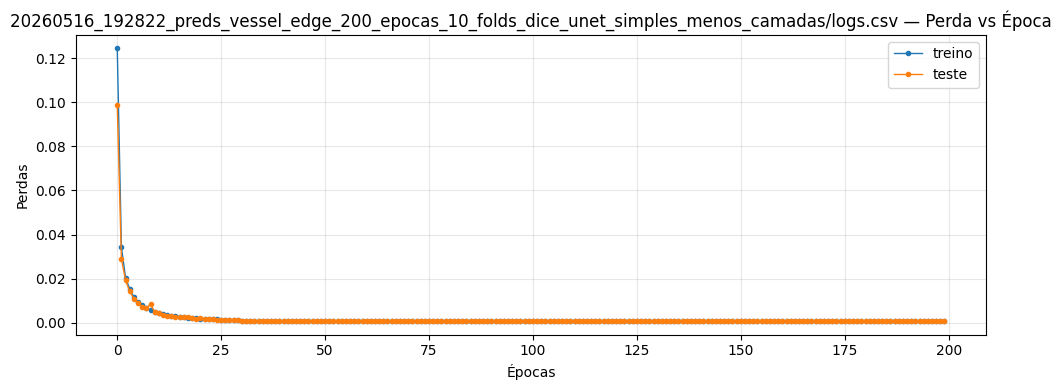


--- 20260517_045850_preds_imagem_edge_200_epocas_10_folds_dice_unet_simples/logs.csv ---


,epoch,fold,dice_train,loss_train,bce_train,accuracy_train,precision_train,f1_train,dice_test,loss_test,bce_test,accuracy_test,precision_test,f1_test
0,0.0,0.0,0.402890,0.597111,1.109592,0.751235,0.359648,0.414820,0.463976,0.536024,0.783343,0.798616,0.366966,0.463979
1,0.0,1.0,0.579883,0.420117,0.527784,0.884716,0.582840,0.602005,0.658394,0.341606,0.393420,0.908150,0.617615,0.677121
2,0.0,2.0,0.644345,0.355654,0.506240,0.899193,0.628787,0.656530,0.667715,0.332285,0.508389,0.913104,0.614488,0.676226
3,0.0,3.0,0.663382,0.336618,0.599542,0.903381,0.641197,0.669790,0.683265,0.316735,0.656890,0.909747,0.616599,0.692815
4,0.0,4.0,0.679527,0.320473,0.622071,0.910627,0.651585,0.684528,0.731596,0.268405,0.663884,0.908567,0.698177,0.736036


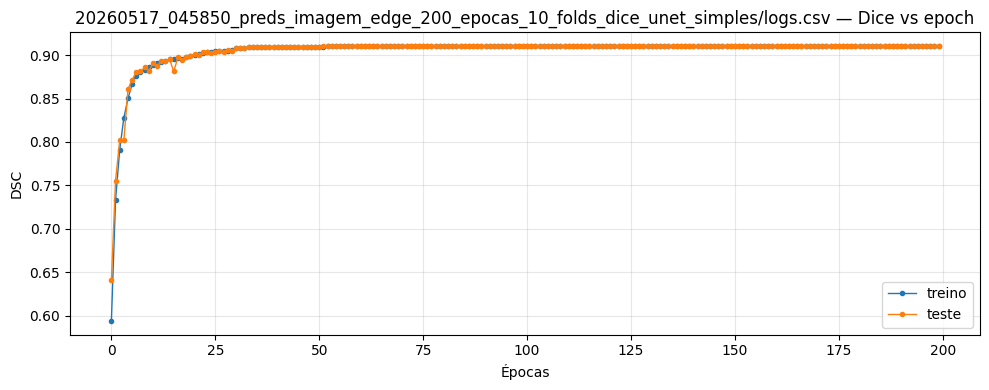

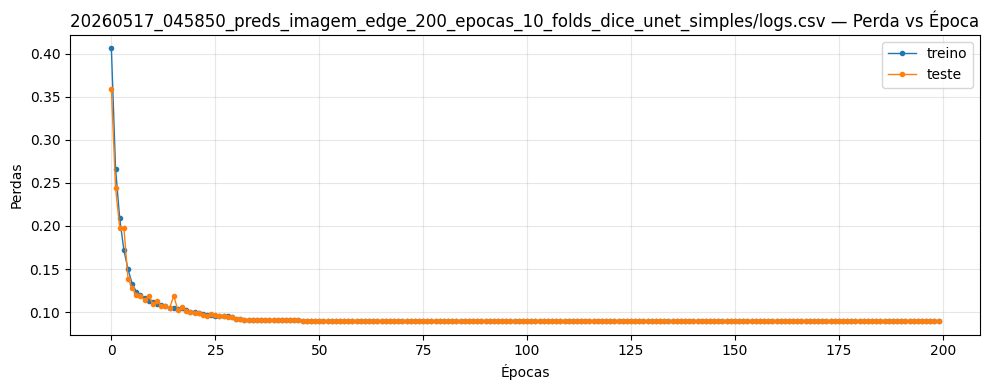

In [23]:
FIGSIZE = (10, 4)
EPOCH_COL = "epoch"
# Typical names from this project's logs: dice_test / loss_test (or dice_train / loss_train)
DICE_COL = "dice_test"
LOSS_COL = "loss_test"
DICE_COL_TRAIN = "dice_train"
LOSS_COL_TRAIN = "loss_train"
AGGREGATE_BY_EPOCH = True  # if True, mean Dice/Loss per epoch when multiple rows share an epoch

from matplotlib.lines import Line2D


def _mark_last_point(ax, epochs, series, line) -> tuple[float, str] | None:
    if len(series) == 0 or pd.isna(series.iloc[-1]):
        return None
    xv, yv = epochs.iloc[-1], series.iloc[-1]
    color = line.get_color()
    ax.scatter([xv], [yv], s=50, zorder=5, color=color, edgecolors="white", linewidths=0.5)
    return yv, color


def _legends(ax, last_entries: list[tuple[str, float, str]]) -> None:
    leg_series = ax.legend(loc="best")
    if not last_entries:
        return
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=8,
            label=f"{name}: {value:.4f}",
        )
        for name, value, color in last_entries
    ]
    ax.legend(handles=handles, title="Última época", loc="lower right", framealpha=0.9)
    ax.add_artist(leg_series)


def plot_epoch_metrics(rel_path: str, df: pd.DataFrame) -> None:
    cols_needed = [EPOCH_COL, DICE_COL, LOSS_COL, DICE_COL_TRAIN, LOSS_COL_TRAIN]
    missing = [c for c in cols_needed if c not in df.columns]
    if missing:
        print(f"{rel_path}: missing columns {missing}. Available: {list(df.columns)}\n")
        return

    work = df[cols_needed].copy()
    for c in (DICE_COL, LOSS_COL, DICE_COL_TRAIN, LOSS_COL_TRAIN):
        work[c] = pd.to_numeric(work[c], errors="coerce")

    if AGGREGATE_BY_EPOCH:
        plot_df = work.groupby(EPOCH_COL, as_index=False)[[DICE_COL, LOSS_COL, DICE_COL_TRAIN, LOSS_COL_TRAIN]].mean().sort_values(EPOCH_COL)
    else:
        plot_df = work.sort_values(EPOCH_COL)

    file_path = rel_path.split("/")[0]
    epochs = plot_df[EPOCH_COL]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    line_train, = ax.plot(epochs, plot_df[DICE_COL_TRAIN], marker="o", markersize=3, linewidth=1, label="treino")
    line_test, = ax.plot(epochs, plot_df[DICE_COL], marker="o", markersize=3, linewidth=1, label="teste")
    last_entries = []
    marked = _mark_last_point(ax, epochs, plot_df[DICE_COL_TRAIN], line_train)
    if marked is not None:
        last_entries.append(("treino", *marked))
    marked = _mark_last_point(ax, epochs, plot_df[DICE_COL], line_test)
    if marked is not None:
        last_entries.append(("teste", *marked))
    ax.set_title(f"{rel_path} — Dice vs epoch")
    # ax.set_title(f"Modelo otimizado por BCE — DSC vs Época")
    ax.set_xlabel("Épocas")
    ax.set_ylabel("DSC")
    _legends(ax, last_entries)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    savefig_1 = f"../support_images/{file_path}‌/dsc_vs_epoch.png".encode('ascii', 'ignore')
    # plt.savefig(savefig_1)
    plt.show()

    fig, ax = plt.subplots(figsize=FIGSIZE)
    line_train, = ax.plot(epochs, plot_df[LOSS_COL_TRAIN], marker="o", markersize=3, linewidth=1, label="treino")
    line_test, = ax.plot(epochs, plot_df[LOSS_COL], marker="o", markersize=3, linewidth=1, color="C1", label="teste")
    last_entries = []
    marked = _mark_last_point(ax, epochs, plot_df[LOSS_COL_TRAIN], line_train)
    if marked is not None:
        last_entries.append(("treino", *marked))
    marked = _mark_last_point(ax, epochs, plot_df[LOSS_COL], line_test)
    if marked is not None:
        last_entries.append(("teste", *marked))
    ax.set_title(f"{rel_path} — Perda vs Época")
    # ax.set_title(f"Modelo otimizado por BCE — Perda vs Época")
    ax.set_xlabel("Épocas")
    ax.set_ylabel("Perdas")
    _legends(ax, last_entries)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    savefig_2 = f"../support_images/{file_path}‌/loss_vs_epoch.png".encode('ascii', 'ignore')
    # plt.savefig(savefig_2)
    plt.show()


if not tables:
    print("No CSV files under support_images yet. Add some, then re-run the discovery cells.")
else:
    for rel_path, df in tables.items():
        print(f"\n--- {rel_path} ---")
        display(df.head())
        plot_epoch_metrics(rel_path, df)
